# Consistency Distillation of Flow-Based Model: Toy Example

In this notebook, we will show a simple example of using a consistency model to distill a pre-trained (with flow-matching) flow-based model on Euclidean space.

In [1]:
import torch
import numpy as np

import tqdm.auto as tqdm
import matplotlib.pyplot as plt

In [2]:
HAS_CUDA = torch.cuda.is_available()
device = torch.device('cuda' if HAS_CUDA else 'cpu')
torch.set_default_device(device)
print('Using device:', device)

Using device: cuda


In [3]:
def grab(inp):
    """Detaches tensor from computational graph and returns as NumPy array."""
    if hasattr(inp, 'detach'):
        return inp.detach().cpu().numpy()
    return inp

The energy function we will try to sample from is quartic: $$E(x) = -(x^2 - 2)^2$$

In [4]:
def sample_target(batch_size, num_iters=100):
    """
    Generates `batch-size` many samples from quartic energy-based density
    p(x) ~ exp(-(x^2 - 2)^2) with Metropolis-Hastings.

    Args:
        batch_size (int): Number of samles to generate
        num_iters (int): Number of Metropolis steps. Default: 100

    Returns:
        (Tensor): Batch of samples from target
    """
    def log_prob(x):  # quartic energy function
        return -(x**2 - 2)**2

    x = torch.zeros(batch_size)
    for _ in tqdm.tqdm(range(num_iters)):
        xp = x + torch.randn(batch_size)
        log_diff = log_prob(xp) - log_prob(x)

        # Accept / reject
        accept = torch.rand(batch_size) < torch.exp(log_diff)
        x = torch.where(accept, xp, x)

    return x.unsqueeze(1)  # [batch_size, 1]

  0%|          | 0/100 [00:00<?, ?it/s]

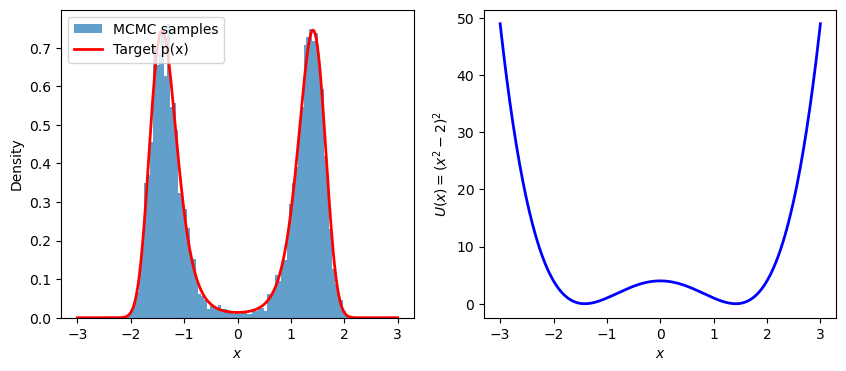

In [5]:
# Visualize the target & training data
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax in axes:
    ax.set_xlabel('$x$')

# Samples and density
n_vis = 8192
samples = sample_target(n_vis)
axes[0].hist(grab(samples), bins=80, density=True, alpha=0.7, label='MCMC samples')

xs = torch.linspace(-3, 3, 300)
logp = -(xs**2 - 2)**2
p_unnorm = torch.exp(logp)
Z = torch.trapz(p_unnorm, xs)
axes[0].plot(grab(xs), grab(p_unnorm / Z), 'r-', lw=2, label='Target p(x)')

axes[0].legend()
axes[0].set_ylabel('Density')

# Energy function
axes[1].plot(grab(xs), grab(-logp), 'b-', lw=2)
axes[1].set_ylabel('$U(x) = (x^2 - 2)^2$')
fig.show()

## Flow Matching

First train a flow-based model with flow matching that will later be distilled.

In [6]:
class VectorField(torch.nn.Module):
    """Simple MLP-parameterization of velocity field for flow-based model."""
    def __init__(self, hidden_dim=128):
        super().__init__()

        self.net = torch.nn.Sequential(
            torch.nn.Linear(2, hidden_dim),  # [x, t] -> input_dim=2
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, t):
        """Feed forward of samples `x` and times `t`."""
        # NOTE: Assume input shape (B, 1) for both `x` and `t`
        fwd = lambda x: self.net(torch.cat([x, t], dim=1))
        return (fwd(x) - fwd(-x)) / 2  # NOTE(OV): antisymmetrize for Z2-equivariance


def _test_vector_field():
    print('[Testing VectorField...]')
    batch_size = 16
    x = torch.randn(batch_size, 1)
    t = torch.rand(batch_size, 1)

    net = VectorField(hidden_dim=8)
    out = net(x, t)

    assert out.shape == x.shape, \
        '[FAILED: vector field should have same shape as input]'
    assert torch.allclose(-out, net(-x, t)), \
        '[FAILED: vector field should be Z2-equivariant]'
    print('[PASSED]')


_test_vector_field()

[Testing VectorField...]
[PASSED]


## Train Flow Matching Model

In [7]:
def train_step(x_1, model, optimizer):
    """Executes a single flow-matching training iteration."""
    t = torch.rand_like(x_1)
    x_0 = torch.randn_like(x_1)
    x_t = (1-t) * x_0 + t * x_1  # linear interpolation x_1 -> x_t
    
    u_t = x_1 - x_0  # constant target velocity
    v_t = model(x_t, t)
    loss = torch.mean((v_t - u_t)**2)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss

In [8]:
from torch.utils.data import TensorDataset, DataLoader

def train_flow_matching(model, train_data, n_epoch, batch_size, lr):
    model.train()
    dataloader = DataLoader(
        TensorDataset(train_data),
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator(device=device)
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []
    for epoch in tqdm.tqdm(range(n_epoch)):
        total_loss = 0
        for x_1, in dataloader:
            loss = train_step(x_1, model, optimizer)
            total_loss += loss.item()
        avg_epoch_loss = total_loss / len(dataloader)
        losses.append(avg_epoch_loss)
        if epoch % 50 == 0:
            print(f'Epoch {epoch}/{n_epoch} | Loss = {avg_epoch_loss:.6f}')
    return model, losses

In [9]:
# Prepare training data
n_train = 8192
train_data = sample_target(n_train)

  0%|          | 0/100 [00:00<?, ?it/s]

In [10]:
flow_model = VectorField(hidden_dim=128)
flow_model, train_loss = train_flow_matching(flow_model, train_data, n_epoch=250, batch_size=256, lr=3e-4)

  0%|          | 0/250 [00:00<?, ?it/s]

Epoch 0/250 | Loss = 2.711050
Epoch 50/250 | Loss = 1.808724
Epoch 100/250 | Loss = 1.813251
Epoch 150/250 | Loss = 1.809344
Epoch 200/250 | Loss = 1.785207


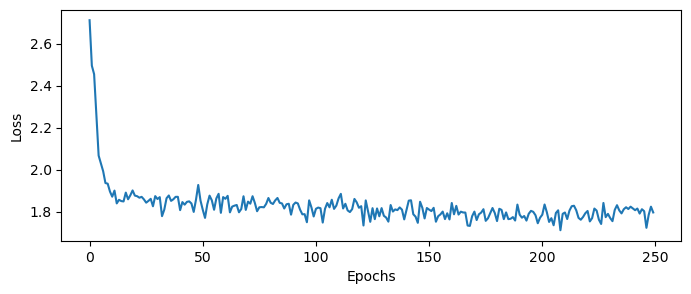

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8,3))
ax.plot(train_loss)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
fig.show()

In [12]:
@torch.no_grad()
def sample_flow(model, n_sample, n_step):
    """Samples `n_sample` many samples from trained flow model using Euler integration."""
    x = torch.randn(n_sample, 1)
    dt = 1 / n_step

    # Integrate from t=0 -> t=1
    for step in tqdm.tqdm(range(n_step)):
        t = step * dt * torch.ones_like(x)
        v = model(x, t)
        x = x + v * dt
    return x

In [13]:
# Sample and compare
flow_samples = sample_flow(flow_model, n_sample=1024, n_step=100)

  0%|          | 0/100 [00:00<?, ?it/s]

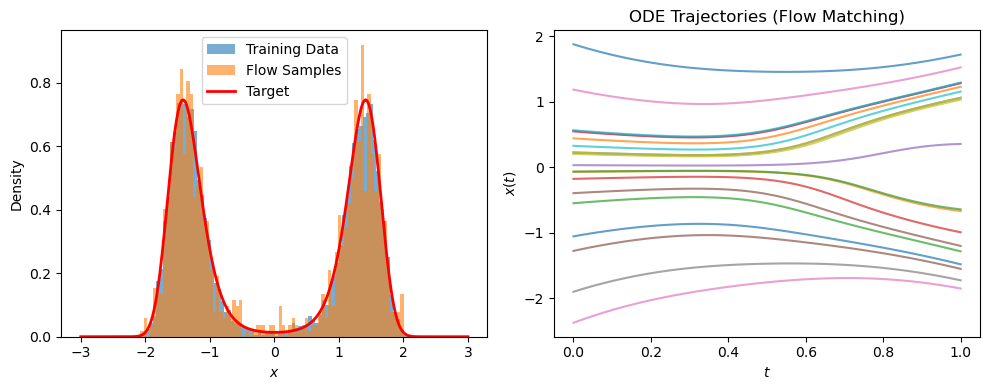

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)

# Compare histograms
axes[0].hist(grab(train_data), bins=80, density=True, alpha=0.6, label='Training Data')
axes[0].hist(grab(flow_samples), bins=80, density=True, alpha=0.6, label='Flow Samples')
axes[0].plot(grab(xs), grab(p_unnorm / Z), 'r-', lw=2, label='Target')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('Density')
axes[0].legend()

# Show trajectories for 8 particles
axes[1].set_title('ODE Trajectories (Flow Matching)')
for _ in range(20):
    x_traj = [torch.randn(1, 1)]
    dt = 1.0 / 50
    for i in range(50):
        t = torch.full((1, 1), i*dt)
        with torch.no_grad():
            v = flow_model(x_traj[-1], t)
        x_traj.append(x_traj[-1] + v*dt)
    traj = torch.cat(x_traj, dim=0).squeeze()
    axes[1].plot(np.linspace(0, 1, 51), grab(traj), alpha=0.7)
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('$x(t)$')

fig.show()

# Consistency Model

Now we use the trained flow model and refine it via distillation into a consistency model.

In [15]:
class ConsistencyModel(torch.nn.Module):
    """
    Simple MLP parameterization of consistency model.

    Note: The identity-map boundary condition is enforced by also
    parameterizing the model as 

        f(x, t) = c_skip(t) * x + c_out(t) * F(x, t)

    where F is the neural net, and the c(t) functions are such that
    c_out(0) = 1, c_skip(0) = 0, and c_out(1) = 0, c_skip(1) = 1.

    Args:
        hidden_dim (int): Hidden dimension of linear layers
    """
    def __init__(self, hidden_dim=128):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(2, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, 1)
        )

    @staticmethod
    def c_skip(t):
        return t
    
    @staticmethod
    def c_out(t):
        return 1 - t

    def forward(self, x, t):
        fwd_out = lambda x: self.net(torch.cat([x, t], dim=1))
        out = (fwd_out(x) - fwd_out(-x)) / 2  # antisymmetrize
        return self.c_skip(t) * x + self.c_out(t) * out

def _test_consistency_model():
    print('[Testing ConsistencyModel...]')
    batch_size = 20
    x = torch.randn((batch_size, 1))
    t = torch.rand((batch_size, 1))
    
    model = ConsistencyModel()
    fx = model(x, t)
    assert torch.allclose(model(x, torch.ones(batch_size, 1)), x), \
        '[FAILED: consistency model must be identity map at t=1]'
    assert torch.allclose(model(-x, t), -fx), \
        '[FAILED: consistency model should be Z2-equivariant]'
    print('[PASSED]')

_test_consistency_model()

[Testing ConsistencyModel...]
[PASSED]


In [16]:
import copy

def get_ema(model, decay=0.999):
    """Creates an EMA copy of the model (used as frozen target network)."""
    ema = copy.deepcopy(model)
    for p in ema.parameters():
        p.requires_grad_(False)
    return ema

@torch.no_grad()
def update_ema(ema_model, model, decay=0.999) -> None:
    """Updates the exponential moving average model parameters."""
    for ema_p, p in zip(ema_model.parameters(), model.parameters()):
        ema_p.data.mul_(decay).add_(p.data, alpha=1-decay)

In [17]:
def make_timesteps(n_step, *, rho=7, eps=0.05):
    """
    Prepares power-law timesteps like those used in 2303.01469.

    Note: The spacing is denser near eps (noise) and sparser
    near t=1 (data boundary). 

    Args:
        n_step (int): Number of timesteps
        rho (float): Step exponent factor. Default: 7
        eps (float): Time interval boundary tolerance. Default: 0.05
    
    Returns:
        (Tensor): Timesteps as a torch tensor
    """
    # Discretize [eps, 1] into n_step steps
    ts = torch.arange(n_step + 1) / n_step
    steps = ts + eps**(1 / rho) * (1 - ts)
    return (steps ** rho).flip(0)  # 1 -> 0

In [18]:
def distillation_train_step(x_1, timesteps, cm, cm_ema, flow_model, optimizer):
    """
    Executes a single step of consistency distillation training.

    Args:
        x_1 (Tensor): Batch of data samples
        cm (Module): Consistency model being trained
        cm_ema (Module): EMA version of consistency model
        flow_model (Module): Pre-trained flow model with frozen parameters
        optimizer (Optimizer): PyTorch optimizer for updating parameters

    Returns
        loss (Tensor): Average distillation loss over the batch
    """
    # Sample a random adjacent pair (n, n+1)
    n_idx = torch.randint(0, len(timesteps)-1, size=(x_1.shape[0],))
    t_n = timesteps[n_idx].unsqueeze(1)
    t_np = timesteps[n_idx + 1].unsqueeze(1)

    # Sample a data point and a noise point
    x_0 = torch.randn_like(x_1)
    x_t_np = (1 - t_np) * x_0 + t_np * x_1
    with torch.no_grad():
        v = flow_model(x_t_np, t_np)
        dt = t_n - t_np
        x_t_n = x_t_np + v*dt  # single Euler step

    # Consistency loss: both should map to same endpoint
    pred_np = cm(x_t_np, t_np)
    with torch.no_grad():
        pred_n_ema = cm_ema(x_t_n.detach(), t_n)
    loss = torch.mean((pred_np - pred_n_ema)**2)
    return loss

In [19]:
def train_consistency_distillation(train_data, flow_model, n_steps, n_epoch, batch_size, lr, ema_decay=0.999):
    """
    Training loop for distilling the flow model into a consistency model.

    For each training step:
        1. Sample x_1 (target data) and x_0 (noise)
        2. Pick adjacent timesteps t_n, t_{n+1} in [0, 1]
        3. Compute x_{n+1} on the interpolation path
        4. Euler step backward to get x_n using frozen flow model
        5. Enforce f(x_{n+1}, t_{n+1}) = f_ema(x_n, t_n)

    Args:
        train_data (Tensor): Training samples from the target density
        flow_model (Module): Pre-trained velocity field
        n_steps (int): Number of ODE steps for evaluating the flow model
        n_epoch (int): Number of training iterations
        batch_size (int): Training batch size
        lr (float): Base learning rate
        ema_decay (float): Strength of the EMA decay. Default: 0.999

    Returns:
        cm (Module): Trained consistency model
        cm_ema (Module): Final iteration of EMA consistency model
        losses (list): History of training loss
    """
    flow_model.eval()
    dataloader = DataLoader(
        TensorDataset(train_data), 
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator(device=device))
    
    cm = ConsistencyModel()
    cm_ema = get_ema(cm)
    optimizer = torch.optim.Adam(cm.parameters(), lr=lr)

    timesteps = make_timesteps(n_steps)
    losses = []
    for epoch in tqdm.tqdm(range(n_epoch), desc='consistency distillation'):
        total_loss = 0
        for x_1, in dataloader:
            loss = distillation_train_step(x_1, timesteps, cm, cm_ema, flow_model, optimizer)
            #loss = loss + 10.0 * (torch.mean((pred_np - x_1)**2) + torch.mean((pred_n - x_1)**2))
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(cm.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_epoch_loss = total_loss / len(dataloader)
        if epoch % 10 == 0:
            print(f'Epoch {epoch}/{n_epoch} | Loss = {avg_epoch_loss:.8f}')
        losses.append(avg_epoch_loss)
        update_ema(cm_ema, cm, decay=ema_decay)
    
    return cm, cm_ema, losses

In [20]:
cm_model, cm_ema, consistency_losses = train_consistency_distillation(
    train_data, flow_model, 
    n_steps = 200,
    n_epoch = 1000,
    batch_size = 256,
    lr = 1e-3,
    ema_decay = 0.9
)
# NOTE(OV): It seems ~5000 epochs are needed to get this model to perform well for single step inference

consistency distillation:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0/1000 | Loss = 0.00014146
Epoch 10/1000 | Loss = 0.00003501
Epoch 20/1000 | Loss = 0.00002175
Epoch 30/1000 | Loss = 0.00001087
Epoch 40/1000 | Loss = 0.00000706
Epoch 50/1000 | Loss = 0.00000511
Epoch 60/1000 | Loss = 0.00000454
Epoch 70/1000 | Loss = 0.00000252
Epoch 80/1000 | Loss = 0.00000188
Epoch 90/1000 | Loss = 0.00000118
Epoch 100/1000 | Loss = 0.00000163
Epoch 110/1000 | Loss = 0.00000138
Epoch 120/1000 | Loss = 0.00000249
Epoch 130/1000 | Loss = 0.00000136
Epoch 140/1000 | Loss = 0.00000257
Epoch 150/1000 | Loss = 0.00000161
Epoch 160/1000 | Loss = 0.00000358
Epoch 170/1000 | Loss = 0.00000279
Epoch 180/1000 | Loss = 0.00000195
Epoch 190/1000 | Loss = 0.00000257
Epoch 200/1000 | Loss = 0.00000192
Epoch 210/1000 | Loss = 0.00000247
Epoch 220/1000 | Loss = 0.00000805
Epoch 230/1000 | Loss = 0.00000254
Epoch 240/1000 | Loss = 0.00000177
Epoch 250/1000 | Loss = 0.00000523
Epoch 260/1000 | Loss = 0.00000176
Epoch 270/1000 | Loss = 0.00000384
Epoch 280/1000 | Loss = 0.00000

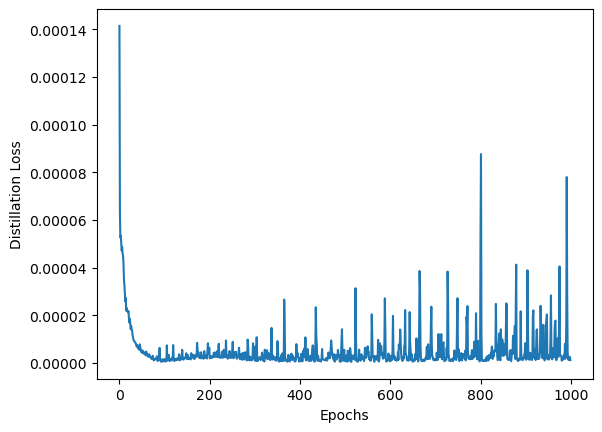

In [21]:
fig, ax = plt.subplots(1, 1)
ax.plot(consistency_losses)
# TODO(OV): stabilize the loss somehow
ax.set_xlabel('Epochs')
ax.set_ylabel('Distillation Loss')
fig.show()

In [22]:
@torch.no_grad()
def sample_consistency_1step(model, batch_size, eps=0.05):
    """Single-step generation: start from noise at t=0(eps), apply f once."""
    x_noise = torch.randn((batch_size, 1))
    t_start = torch.full((batch_size, 1), eps)
    return model(x_noise, t_start)


@torch.no_grad()
def sample_consistency_nstep(model, batch_size, n_step, eps=0.05):
    """Multi-step consistency sampling.

    Jump from t=0 -> t_k -> ... -> t_1 -> 1.
    Each step: decode to x_1, re-noise to next t, decode again.
    """
    schedule = torch.linspace(eps, 1.0, n_step+1)

    x = torch.randn((batch_size, 1))
    t = torch.ones((batch_size, 1))

    for i in range(n_step):
        x_1_pred = model(x, t)
        if i < n_step - 1:
            t_next = torch.full((batch_size, 1), schedule[i+1].item())
            noise = torch.randn_like(x_1_pred)
            x = (1 - t_next) * noise + t_next * x_1_pred  # re-noise
            t = t_next
    return x_1_pred

  0%|          | 0/100 [00:00<?, ?it/s]

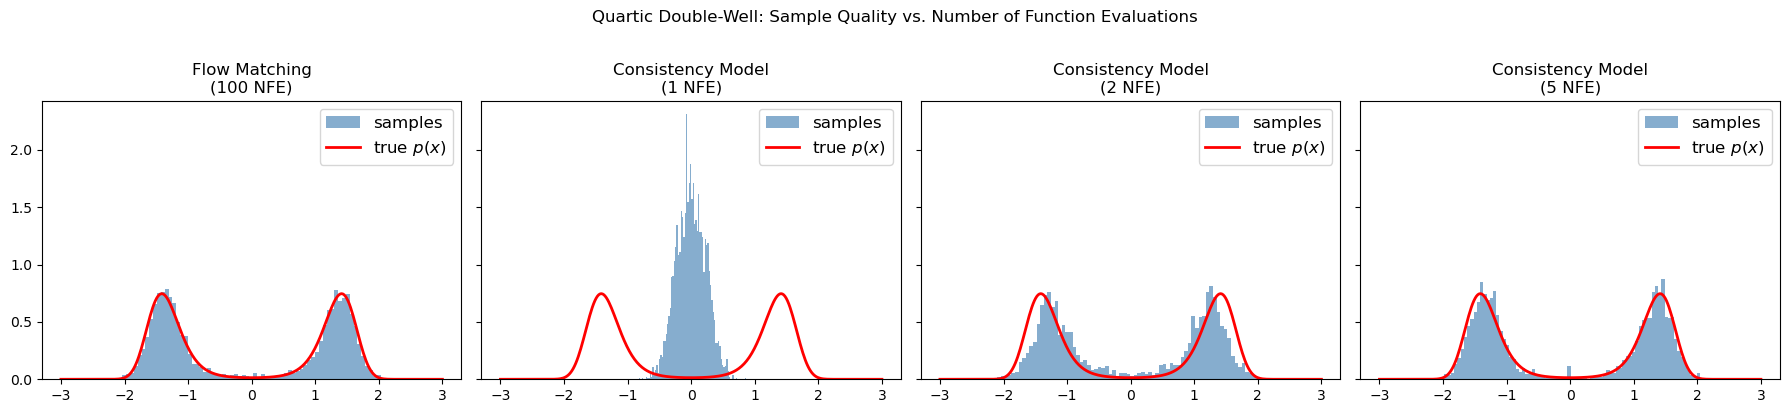

In [23]:
# --- Compare all methods ---
samples_1step = sample_consistency_1step(cm_ema, 4096)
samples_2step = sample_consistency_nstep(cm_ema, 4096, n_step=2)
samples_5step = sample_consistency_nstep(cm_ema, 4096, n_step=5)
samples_flow = sample_flow(flow_model, n_sample=4096, n_step=100)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
p_true = grab(p_unnorm / Z)

def plot_comparison(ax, samples, title):
    ax.hist(grab(samples), bins=80, density=True, alpha=0.65, color='steelblue', label='samples')
    ax.plot(grab(xs), grab(p_true), 'r-', lw=2, label='true $p(x)$')
    ax.set_title(title); ax.legend(fontsize=12)

plot_comparison(axes[0], grab(samples_flow),  'Flow Matching\n(100 NFE)')
plot_comparison(axes[1], grab(samples_1step), 'Consistency Model\n(1 NFE)')
plot_comparison(axes[2], grab(samples_2step), 'Consistency Model\n(2 NFE)')
plot_comparison(axes[3], grab(samples_5step), 'Consistency Model\n(5 NFE)')

plt.suptitle("Quartic Double-Well: Sample Quality vs. Number of Function Evaluations", y=1.02)
plt.tight_layout(); plt.show()

In [24]:
# Sanity check: boundary condition enforced?
x_test = torch.randn((5, 1))
t_0 = torch.zeros_like(x_test)
t_1 = torch.ones_like(x_test)
print('x =', grab(x_test))
print('f(x, t=1) =', grab(cm_model(x_test, t_1)))  # boundary, should = x
print('f(x, t=0) =', grab(cm_model(x_test, t_0)))  # free model output

x = [[-0.46877906]
 [ 0.91001815]
 [ 2.1825626 ]
 [ 0.8175911 ]
 [ 1.2592672 ]]
f(x, t=1) = [[-0.46877906]
 [ 0.91001815]
 [ 2.1825626 ]
 [ 0.8175911 ]
 [ 1.2592672 ]]
f(x, t=0) = [[-0.03854804]
 [ 0.07046743]
 [ 0.15736592]
 [ 0.06646563]
 [ 0.08245829]]


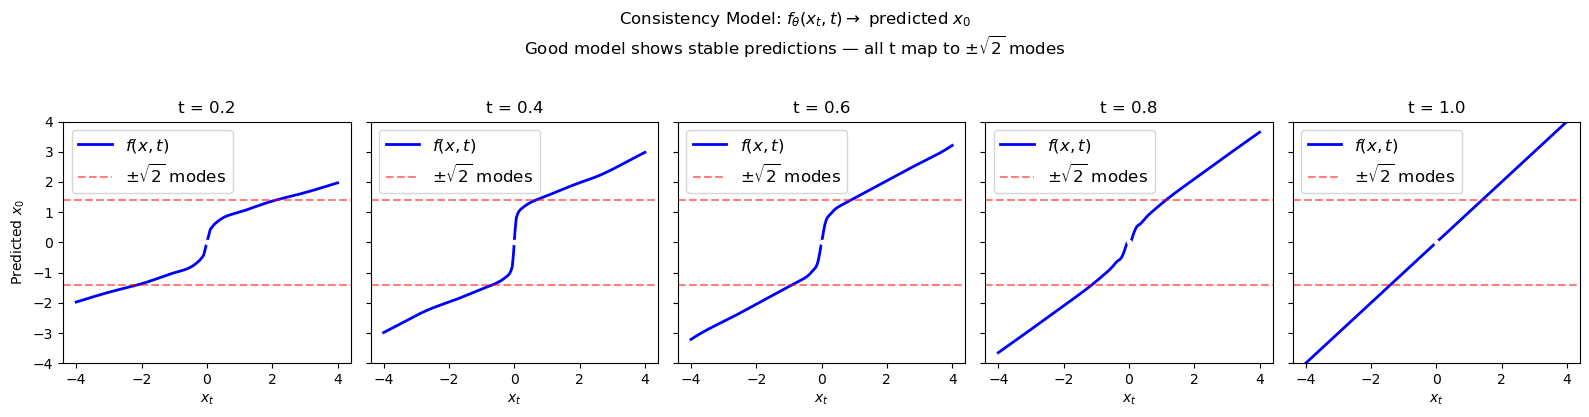

In [25]:
@torch.no_grad()
def plot_consistency_field(model):
    """
    For each (x, t) in a grid, show what x0 the model predicts.
    
    Note: A good consistency model should have consistent predictions 
    across t, except for t=1 since this is the boundary (data).
    """
    ts = [0.2, 0.4, 0.6, 0.8, 1.0]
    x_range = torch.linspace(-4, 4, 200).unsqueeze(1)

    fig, axes = plt.subplots(1, len(ts), figsize=(16, 4), sharey=True, tight_layout=True)

    for ax, t_val in zip(axes, ts):
        t_tensor = torch.full((200, 1), t_val)
        x0_pred = grab(model(x_range, t_tensor))

        ax.plot(grab(x_range), x0_pred, 'b-', lw=2, label='$f(x, t)$')
        ax.axhline(np.sqrt(2),  color='r', ls='--', alpha=0.5, label=r'$\pm \sqrt{2}$ modes')
        ax.axhline(-np.sqrt(2), color='r', ls='--', alpha=0.5)
        ax.plot([0], [0], 'w.')  # invisible for spacing
        ax.set_title(f"t = {t_val:.1f}")
        ax.set_xlabel('$x_t$')
        if ax == axes[0]:
            ax.set_ylabel('Predicted $x_0$')
        ax.legend(fontsize=12)
        ax.set_ylim(-4, 4)

    fig.suptitle(r'Consistency Model: $f_\theta(x_t, t) \rightarrow$ predicted $x_0$' +'\n'
                 r'Good model shows stable predictions — all t map to $\pm \sqrt{2}$ modes',
                 y=1.03)
    fig.show()

plot_consistency_field(cm_ema)